In [78]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr

In [117]:
#j0,j1,i0,i1 = -75.25,-70,-120,-90 #Amundsen
#jj,ii = 8,52

#j0,j1,i0,i1 = -79,-74,-180,-140 #Ross East
#jj,ii = 8,8

#j0,j1,i0,i1 = -79,-74,160,180 #Ross West
#jj,ii = 8,20

j0,j1,i0,i1 = -79,-74,-70,0 #Weddell
jj,ii = 6,120

/tmp/ipykernel_2520542/788778878.py:6: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(ds.lon,ds.lat,T_woa[0,:,:])


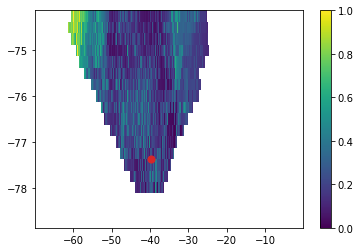

In [118]:
ds = xr.open_dataset('/usr/people/lambert/work/projects/data/woa23/woa23_decav91C0_t00_04.nc',decode_cf=False)
ds = ds.isel(time=0)
ds = ds.sel(lon=slice(i0,i1),lat=slice(j0,j1))
#ds
T_woa = np.where(ds.t_an<1e30,ds.t_an,np.nan)
plt.pcolormesh(ds.lon,ds.lat,T_woa[0,:,:])
plt.scatter(ds.lon[ii],ds.lat[jj],50,c='tab:red')
plt.colorbar()
ds.close()

ds = xr.open_dataset('/usr/people/lambert/work/projects/data/woa23/woa23_decav91C0_s00_04.nc',decode_cf=False)
ds = ds.isel(time=0)
ds = ds.sel(lon=slice(i0,i1),lat=slice(j0,j1))
#ds
S_woa = np.where(ds.s_an<1e30,ds.s_an,np.nan)
ds

#Get volume
Vw = np.zeros((len(ds.depth),len(ds.lat),len(ds.lon)))
R = 6.371e6
A = np.ones((len(ds.lat),len(ds.lon)))
for l in range(len(ds.lat)):
    dy = 2*np.pi*R*(ds.lat_bnds[l,1]-ds.lat_bnds[l,0])/360
    dx = 2*np.pi*R*(ds.lon_bnds[:,1]-ds.lon_bnds[:,0])/360 * np.cos(2*np.pi*ds.lat[l]/360)
    A[l,:] = dx*dy

for d in range(len(ds.depth)):
    D = np.where(np.isnan(T_woa[d,:,:]),0,ds.depth_bnds[d,1]-ds.depth_bnds[d,0])
    Vw[d,:,:] = D*A
#V_woa

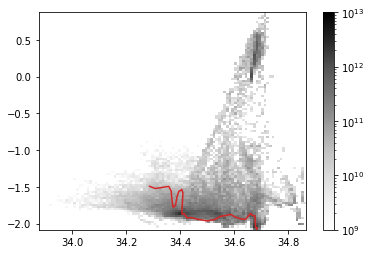

In [119]:
V_woa,Sb_woa,Tb_woa = np.histogram2d(S_woa.flatten()[Vw.flatten()>0],T_woa.flatten()[Vw.flatten()>0],bins=100,weights=Vw.flatten()[Vw.flatten()>0])
plt.pcolormesh(Sb_woa,Tb_woa,V_woa.T,norm=mpl.colors.LogNorm(vmin=1e9,vmax=1e13),cmap='Greys')
plt.colorbar()
plt.plot(S_woa[:,jj,ii],T_woa[:,jj,ii],c='tab:red')

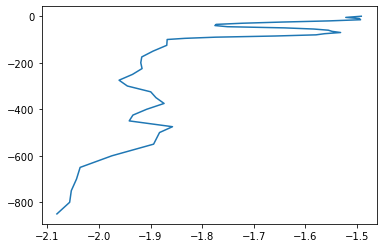

In [120]:
plt.plot(T_woa[:,jj,ii],-ds.depth)